In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import tensorflow as tf
from scipy import stats
import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow import keras
from keras import layers
import keras.backend as K
import matplotlib.pyplot as plt
import japanize_matplotlib
import math
from sklearn.metrics import mean_squared_error
from statistics import mean
import pickle
import calendar
import random
import os

from collections import defaultdict
%precision 3

/home/matsumoto/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
2023-01-18 19:10:01.869838: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


'%.3f'

In [2]:
LOOK_BACK = 14 # 予測に使うタイムステップ数
EPOCHS = 50 # 訓練時のエポック数
BATCH_SIZE = 32 # 訓練時のバッチサイズ(元：32)
DATA_FILE_NAME = 'New_data(all).xlsx' # データを読み込むファイル名

In [3]:
#乱数を固定(毎回同じ予測結果がでるようにする)
def set_seed(seed=0):
    tf.random.set_seed(seed)

    # optional
    # for numpy.random
    np.random.seed(seed)
    # for built-in random
    random.seed(seed)
    # for hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)

In [4]:
#損失関数のグラフを表示
def draw_history(history):
    plt.plot(history.history['loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train'], loc='upper left')
    plt.show()

In [5]:
#95%信頼区間を求める
def MeanCI(data):
    u_var = np.var(data, ddof=1)
    s_mean = np.mean(data)
    deg_of_freedom = len(data)-1
    # t分布の両側2.5%で区間推定する
    bottom, up = sp.stats.t.interval(
        alpha=0.95, # 信頼区間
        loc=s_mean,  # 標本平均
        scale=np.sqrt(u_var/len(data)), # 標準誤差(推定量の標準偏差)
        df=deg_of_freedom # 自由度
    )
    return (bottom,up)

In [6]:
def make_dataset_train(data, look_back):
    X = []
    y = []
    for i in range(len(data) - look_back * 2 + 1):
        X.append(data[i : i + look_back])
        y.append(data[i + look_back : i + 2 * look_back])
    X = np.array(X).reshape(len(X), look_back, 1)
    y = np.array(y).reshape(len(y), look_back, 1)
    return X, y

In [7]:
def make_dataset_test(data, look_back):
    X = []
    for i in range(len(data) - look_back + 1):
        X.append(data[i : i + look_back])
    X = np.array(X).reshape(len(X), look_back, 1)
    return X

In [8]:
def model_phase7():
    global train_data,LOOK_BACK
    
    #モデルを定義
    input = keras.Input(shape=(LOOK_BACK,len(train_data.columns)), name='Input')
    lstm1 = layers.Bidirectional(layers.LSTM(300, return_sequences=True),name='bd_LSTM')(input)
    Seq2=tf.reshape(lstm1, [-1,600*14])
    Lin1=layers.Dropout(0)(layers.Dense(3000,activation="relu")(Seq2))
    Lin2=layers.Dropout(0)(layers.Dense(1500,activation="relu")(Lin1))
    Lin3=layers.Dropout(0)(layers.Dense(500,activation="relu")(Lin2))
    La = layers.Dense(LOOK_BACK,activation="sigmoid")(Lin3)

    # モデルをコンパイル
    model = keras.Model(inputs=input, outputs=La, name='CovidNet')
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['accuracy'])
    model.summary()
    return model

In [9]:
def model_phase8():
    global train_data,LOOK_BACK
    
    #モデルを定義
    input = keras.Input(shape=(LOOK_BACK,len(train_data.columns)), name='Input')
    lstm1 = layers.Bidirectional(layers.LSTM(300, return_sequences=True),name='bd_LSTM')(input)
    Seq2=tf.reshape(lstm1, [-1,600*14])
    Lin1=layers.Dropout(0.2)(layers.Dense(3000,activation="relu")(Seq2))
    Lin2=layers.Dropout(0.2)(layers.Dense(1500,activation="relu")(Lin1))
    Lin3=layers.Dropout(0.2)(layers.Dense(500,activation="relu")(Lin2))
    La = layers.Dense(LOOK_BACK,activation="sigmoid")(Lin3)

    # モデルをコンパイル
    model = keras.Model(inputs=input, outputs=La, name='CovidNet')
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['accuracy'])
    model.summary()
    return model

In [10]:
def Mean(L):
    res=0
    for l in L:
        res+=max(0,l)
    return res/len(L)

In [11]:
def day_add(ymd,plus_day):
    if type(ymd)!=datetime.datetime:
        y1,m1,d1=ymd
        ymd=datetime.datetime(y1,m1,d1)
    return ymd+datetime.timedelta(days=plus_day)

In [12]:
#エクセルからデータを取得
def make_all_data():
    past_data=pd.read_excel(DATA_FILE_NAME, sheet_name="Past", header=None, skiprows=2, usecols=[1,2,3,4,6], engine="openpyxl")
    train_data = pd.read_excel(DATA_FILE_NAME, sheet_name="Training", header=None, skiprows=2, usecols=[1,2,3,4,6], engine="openpyxl")
    test_data = pd.read_excel(DATA_FILE_NAME, sheet_name="Testing", header=None, skiprows=2, usecols=[1,2,3,4,5], engine="openpyxl")
    past_data=past_data.rename(columns={6:5})
    train_data=train_data.rename(columns={6:5})
    all_data=pd.concat([past_data,train_data, test_data], axis=0, ignore_index=True)
    all_data=all_data.dropna()
    date=pd.date_range('2020-02-18', periods=len(all_data), freq='d')
    all_data=all_data.set_index(date)
    return all_data

In [13]:
#元データから7日間平均のデータを作成
def make_mean_all_data():
    data=[]
    for i in range(1,6):
        data.append(list(all_data[i]))
    mean_data=[]
    for i in range(5):
        md=[]
        for j in range(3,np.shape(data)[1]-3):
            md.append(mean(data[i][j-3:j+4]))
        mean_data.append(md)
    mean_data=np.array(mean_data)
    mean_all_data=pd.DataFrame(data=mean_data.T)
    date=pd.date_range('2020-02-21', periods=len(all_data)-6, freq='d')
    mean_all_data=mean_all_data.set_index(date)
    return mean_all_data

In [14]:
#学習したモデルが訓練データにどれくらいフィットしてるか確認
def train_data_graph(a,b,c,d):
    global LOOK_BACK,train_data
    #グラフを表示する領域を，figオブジェクトとして作成．
    fig = plt.figure(figsize = (6,4), facecolor='lightblue')

    #グラフを描画するsubplot領域を作成。
    ax1 = fig.add_subplot(1, 1, 1)

    true_value=list(train_data[4])
    true_value=true_value[LOOK_BACK:]
    true_value=np.expm1(true_value)
    x=range(len(a))

    ax1.plot(x,true_value,color="blue")
    ax1.plot(x,a,color="red")
    ax1.plot(x,b,color="red",linestyle='dashed')
    ax1.plot(x,c,color="red",linestyle='dashed')
    ax1.set_title("自作モデル RMSE="+str(mean_squared_error(a,true_value,squared=False)))
    ax1.legend(['実測値',"予測値","最大値","最小値"], loc='upper left')

In [15]:
#グラフを表示
def test_data_graph(a,b,c,d):
    global train_data,test_data,test_day
    #グラフを表示する領域を，figオブジェクトとして作成．
    fig = plt.figure(figsize = (6,4), facecolor='lightblue')

    #グラフを描画するsubplot領域を作成。
    ax1 = fig.add_subplot(1, 1, 1)
    ax=[ax1]

    true_value=list(test_data[test_day[0]:][4])
    true_value=np.expm1(true_value)
    y1=train_data[4]
    y2=test_data[datetime.datetime.strptime(test_day[0],'%Y-%m-%d')-datetime.timedelta(days=1):][4]
    y1=np.expm1(y1)
    y2=np.expm1(y2)
    for axi in ax:
        axi.set_xlabel('日数[day]')
        axi.tick_params(axis='x', labelrotation=20)
        axi.set_ylabel('感染者数[人]')
        axi.plot(train_data.index,y1,color="black")
        axi.plot(test_data[datetime.datetime.strptime(test_day[0],'%Y-%m-%d')-datetime.timedelta(days=1):].index,y2,color="green")
        axi.grid()
    ax1.set_title("テストデータの予測値"+" RMSE="+str(mean_squared_error(a[LOOK_BACK:-(LOOK_BACK-1)],y2[1:],squared=False)))
    ax1.plot(test_data[test_day[0]:].index,a[LOOK_BACK:-(LOOK_BACK-1)],color="red")
    ax1.plot(test_data[test_day[0]:].index,b[LOOK_BACK:-(LOOK_BACK-1)],color="red",linestyle='dashed')
    ax1.plot(test_data[test_day[0]:].index,c[LOOK_BACK:-(LOOK_BACK-1)],color="red",linestyle='dashed')
    ax1.legend(['実測値','実測値',"予測値","最大値","最小値"], loc='upper left')

    plt.show()

In [16]:
#グラフを表示
def predict_result_graph(a,b,c,d):
    global train_data,test_data,test_day
    #グラフを表示する領域を，figオブジェクトとして作成．
    fig = plt.figure(figsize = (6,4), facecolor='lightblue')

    #グラフを描画するsubplot領域を作成。
    ax1 = fig.add_subplot(1, 1, 1)
    ax=[ax1]

    true_value=list(test_data[test_day[0]:][4])
    y1=train_data[4]
    y2=test_data[datetime.datetime.strptime(test_day[0],'%Y-%m-%d')-datetime.timedelta(days=1):][4]
    y1=np.expm1(y1)
    y2=np.expm1(y2)

    for axi in ax:
        axi.set_xlabel('日数[day]')
        axi.tick_params(axis='x', labelrotation=20)
        axi.set_ylabel('感染者数[人]')
        axi.plot(train_data.index,y1,color="black")
        axi.plot(test_data[datetime.datetime.strptime(test_day[0],'%Y-%m-%d')-datetime.timedelta(days=1):].index,y2,color="green")
        axi.grid()
    d1=[dd[1] for dd in d]
    d2=[dd[0] for dd in d]
    ax1.set_title("テストデータの予測値"+" RMSE="+str(mean_squared_error(a[:-LOOK_BACK],y2[1:],squared=False)))
    ax1.plot(test_data[test_day[0]:].index,a[:-LOOK_BACK],color="red")
    ax1.plot(test_data[test_day[0]:].index,d1[:-LOOK_BACK],color="red",linestyle='dashed')
    ax1.plot(test_data[test_day[0]:].index,d2[:-LOOK_BACK],color="red",linestyle='dashed')
    ax1.legend(['実測値','実測値',"予測値","95%上","95%下"], loc='upper left')

    plt.show()

In [17]:
def predict_result(model,x_test,scaler_list):
    global LOOK_BACK
    x2=model.predict(x_test)
    x2=scaler_list[-1].inverse_transform(x2)
    x2=np.expm1(x2)

    a,b=np.shape(x2)
    x2=x2.tolist()
    x3=[["NULL"]*b for _ in range(a+b-1)]
    for i in range(a):
        for j in range(b):
            x3[i+j][j]=x2[i][j]

    a=[] #mean
    b=[] #max
    c=[] #min
    d=[] #95%信頼区間
    for x in x3:
        cnt=x.count("NULL")
        if x[0]=="NULL":
            xx=x[cnt:]
        else:
            xx=x[:LOOK_BACK-cnt]

        a.append(max(0,mean(xx))) #14個の予測値の平均をとる
        b.append(max(0,max(xx)))  #14個の予測値の最大値をとる
        c.append(max(0,min(xx)))  #14個の予測値の最小値をとる
        bottom,up=MeanCI(xx)      #14個の予測値から95%信頼区間を求める
        d.append((max(0,bottom),max(0,up)))
    return a,b,c,d

In [18]:
#予測開始日
def future_predict(model):
    from collections import defaultdict
    import copy
    global one_day,x_test,matomeX
    global model_NN
    global LOOK_BACK
    result=defaultdict(list)
    s_day=datetime.datetime.strptime(test_day[0],'%Y-%m-%d')+datetime.timedelta(days=-(LOOK_BACK*2-1))+datetime.timedelta(days=LOOK_BACK)
    push=[]
    use_data=x_test

    for j in range(len(use_data)):
        nxt_material=copy.deepcopy(use_data[j])
        for k in range(len(push)):
            nxt_material[-(k+1)][-1]=push[k]
        predict=model.predict([nxt_material.tolist()],verbose=0)
        predict=scaler_list[-1].inverse_transform(predict)
        predict=np.expm1(predict)
        now_day=day_add(s_day,j)
        for i in range(LOOK_BACK):
            result[day_add(now_day,i).strftime('%Y/%m/%d')].append(predict[0][i])
            if len(result[day_add(now_day,i).strftime('%Y/%m/%d')])==LOOK_BACK:
                s=0
                for r in result[day_add(now_day,i).strftime('%Y/%m/%d')]:
                    s+=max(0,r)
                p=s/LOOK_BACK
                p=np.log1p(p)
                p=scaler_list[-1].transform([[p]])
                push.append(p[0][0])
                if len(push)>LOOK_BACK:
                    push=push[1:LOOK_BACK+1]
    return result

In [19]:
all_data=make_all_data()
mean_all_data=make_mean_all_data() #7日間の平均をとる
mean_all_data[4]=np.log1p(mean_all_data[4]) #感染者数を対数変換
mean_all_data

,0,1,2,3,4
2020-02-21,-5.463882,3.389831,76.857143,0.000000,1.049822
2020-02-22,-5.934632,3.389831,72.714286,0.000000,0.887303
2020-02-23,-6.408182,3.389831,74.285714,0.000000,0.887303
2020-02-24,-7.336029,3.389831,74.428571,0.000000,0.944462
2020-02-25,-8.533692,3.389831,69.857143,0.000000,0.762140
...,...,...,...,...,...
2023-02-21,-22.960324,30.915254,47.914286,0.561750,0.000000
2023-02-22,-23.181432,30.915254,48.514286,0.561416,0.000000
2023-02-23,-24.139127,30.915254,48.171429,0.561048,0.000000
2023-02-24,-22.699199,30.915254,46.114286,0.560657,0.000000


In [20]:
train_day=["2022-1","2022-8"] #訓練データの期間を決める
test_day=["2022-9-1","2022-10"] #テストデータの期間を決める

#訓練データとテストデータに分ける
train_data=mean_all_data[train_day[0]:train_day[1]]
test_data=mean_all_data[datetime.datetime.strptime(test_day[0],'%Y-%m-%d')+datetime.timedelta(days=-(LOOK_BACK*2-1)):test_day[1]]

In [21]:
# #変数ごとにデータを正規化
scaler_list = [MinMaxScaler(feature_range=(0.2,0.8)) for _ in range(len(train_data.columns))]

#訓練データの正規化
x_train_list = []
for i in range(len(train_data.columns)):
    x = np.array(train_data.iloc[:, i])
    x_normalized = scaler_list[i].fit_transform(x.reshape(-1, 1))
    x_train_list.append(x_normalized.squeeze())

#テストデータの正規化
x_test_list = []
for i in range(len(test_data.columns)):
    x = np.array(test_data.iloc[:, i])
    x_normalized = scaler_list[i].transform(x.reshape(-1, 1))
    x_test_list.append(x_normalized.squeeze())

MAX=max(mean_all_data[4][train_day[0]:train_day[1]])
print("訓練データの最大値："+str(np.expm1(MAX)))
print("予測できる最大の値(対数変換なし)："+str(np.expm1(MAX)/0.8))
print("予測できる最大の値(対数変換あり)："+str(np.expm1(MAX/0.8)))

訓練データの最大値：33402.71428571429
予測できる最大の値(対数変換なし)：41753.39285714286
予測できる最大の値(対数変換あり)：451588.0995997721


In [22]:
#各変数のデータセットを作成
x1, _ = make_dataset_train(x_train_list[0], LOOK_BACK)
x2, _ = make_dataset_train(x_train_list[1], LOOK_BACK)
x3, _ = make_dataset_train(x_train_list[2], LOOK_BACK)
x4, _ = make_dataset_train(x_train_list[3], LOOK_BACK)
x5, y_train = make_dataset_train(x_train_list[4], LOOK_BACK)
x_train = np.concatenate([x1, x2, x3, x4, x5], axis=2)
y_train=y_train.reshape(len(y_train),LOOK_BACK)

In [23]:
x1= make_dataset_test(x_test_list[0], LOOK_BACK)
x2= make_dataset_test(x_test_list[1], LOOK_BACK)
x3= make_dataset_test(x_test_list[2], LOOK_BACK)
x4= make_dataset_test(x_test_list[3], LOOK_BACK)
x5= make_dataset_test(x_test_list[4], LOOK_BACK)
x_test = np.concatenate([x1, x2, x3, x4, x5], axis=2)

In [24]:
print("訓練データ："+str(np.shape(x_train))+" テストデータ："+str(np.shape(x_test)))

訓練データ：(216, 14, 5) テストデータ：(75, 14, 5)


In [25]:
set_seed(0) #dafault:0
model=model_phase7()

2023-01-18 19:10:04.373548: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudnn.so.8'; dlerror: libcudnn.so.8: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/intel/compilers_and_libraries_2019.0.117/linux/compiler/lib/intel64_lin:/opt/intel//compilers_and_libraries_2019.0.117/linux/mpi/intel64/libfabric/lib:/opt/intel//compilers_and_libraries_2019.0.117/linux/mpi/intel64/lib/release:/opt/intel//compilers_and_libraries_2019.0.117/linux/mpi/intel64/lib:/opt/intel/compilers_and_libraries_2019.0.117/linux/tbb/lib/intel64_lin/gcc4.1:/opt/intel/compilers_and_libraries_2019.0.117/linux/compiler/lib/intel64_lin:/opt/intel/compilers_and_libraries_2019.0.117/linux/mkl/lib/intel64_lin:/opt/intel/debugger_2019/libipt/intel64/lib:/home/matsumoto/usr/lib:/opt/FJSVplang/lib64:
2023-01-18 19:10:04.373567: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1850] Cannot dlopen some GPU libraries. Please make sure the 

Model: "CovidNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 14, 5)]           0         
                                                                 
 bd_LSTM (Bidirectional)     (None, 14, 600)           734400    
                                                                 
 tf.reshape (TFOpLambda)     (None, 8400)              0         
                                                                 
 dense (Dense)               (None, 3000)              25203000  
                                                                 
 dropout (Dropout)           (None, 3000)              0         
                                                                 
 dense_1 (Dense)             (None, 1500)              4501500   
                                                                 
 dropout_1 (Dropout)         (None, 1500)              0  

In [26]:
#訓練データの並びをランダムにシャッフルする(バッチサイズ関連で効いてくる)
x_train_shuffled=[]
y_train_shuffled=[]
L=len(x_train)
ind=[i for i in range(L)]
random.shuffle(ind)
for index in ind:
    x_train_shuffled.append(x_train[index].tolist())
    y_train_shuffled.append(y_train[index].tolist())
x_train_shuffled=np.array(x_train_shuffled)
y_train_shuffled=np.array(y_train_shuffled)

In [27]:
#モデルを学習させる
history = model.fit(x_train_shuffled, y_train_shuffled, epochs=EPOCHS, batch_size=BATCH_SIZE,verbose=1)

Epoch 1/50
7/7 [==============================] - 4s 54ms/step - loss: 0.0145 - accuracy: 0.1389
Epoch 2/50
7/7 [==============================] - 0s 46ms/step - loss: 0.0040 - accuracy: 0.0185
Epoch 3/50
7/7 [==============================] - 0s 48ms/step - loss: 0.0021 - accuracy: 0.0463
Epoch 4/50
7/7 [==============================] - 0s 62ms/step - loss: 0.0014 - accuracy: 0.2130
Epoch 5/50
7/7 [==============================] - 0s 56ms/step - loss: 0.0012 - accuracy: 0.1944
Epoch 6/50
7/7 [==============================] - 0s 57ms/step - loss: 9.2012e-04 - accuracy: 0.3935
Epoch 7/50
7/7 [==============================] - 0s 44ms/step - loss: 6.2795e-04 - accuracy: 0.2870
Epoch 8/50
7/7 [==============================] - 0s 59ms/step - loss: 5.2993e-04 - accuracy: 0.3704
Epoch 9/50
7/7 [==============================] - 0s 59ms/step - loss: 3.1921e-04 - accuracy: 0.4491
Epoch 10/50
7/7 [==============================] - 0s 59ms/step - loss: 3.5393e-04 - accuracy: 0.3565
Epoch 11/

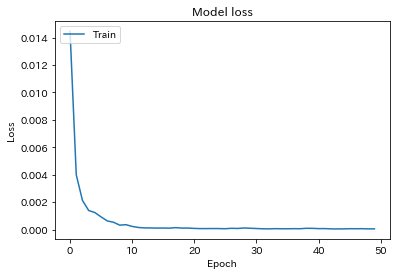

In [28]:
#損失関数の値の遷移をグラフで表示
draw_history(history)

In [29]:
#訓練データの学習結果を求める
a,b,c,d=predict_result(model,x_train,scaler_list)

7/7 [==============================] - 1s 26ms/step


/home/matsumoto/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3715: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/matsumoto/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


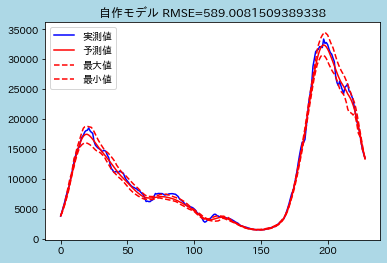

In [30]:
train_data_graph(a,b,c,d)

In [31]:
a,b,c,d=predict_result(model,x_test,scaler_list)

3/3 [==============================] - 0s 22ms/step


/home/matsumoto/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3715: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/matsumoto/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


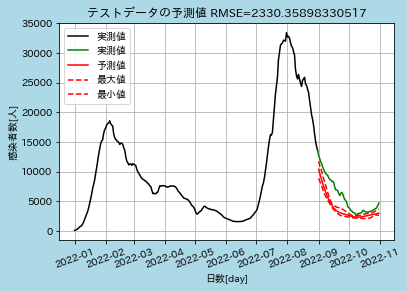

In [32]:
test_data_graph(a,b,c,d)

In [33]:
result=future_predict(model)
a=[]
b=[]
c=[]
d=[]
cnt=1
for values in result.values():
    if cnt<=LOOK_BACK-1:
        cnt+=1
        continue
    a.append(Mean(values))
    b.append(max(0,max(values)))
    c.append(max(0,min(values)))
    bottom,up=MeanCI(values)
    bottom=max(0,bottom)
    up=max(0,up)
    d.append((bottom,up))

/home/matsumoto/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3715: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/matsumoto/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


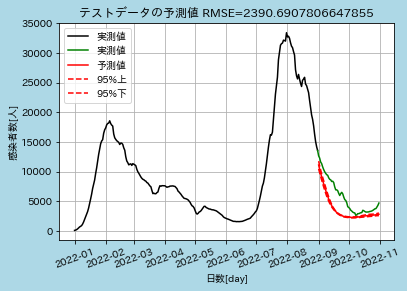

In [34]:
predict_result_graph(a,b,c,d)

# ファインチューニング

In [35]:
#訓練データの後ろから180個のデータをファインチューニング用に持ってくる
x_train_after=x_train[len(x_train)-180:]
y_train_after=y_train[len(y_train)-180:]

In [36]:
set_seed(0) #dafault:0
flatten = model.layers[-2].output
fc1=layers.Dropout(0.1)(layers.Dense(30,activation="relu")(flatten))
fc2= layers.Dense(LOOK_BACK,activation="sigmoid")(fc1)
new_model = Model(inputs=model.inputs, outputs=fc2)
print("Do not train:")
for i in range(9):
    new_model.layers[i].trainable=False
    print(new_model.layers[i].name,end=", ")
print()
new_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['accuracy'])
new_model.summary()

Do not train:
Input, bd_LSTM, tf.reshape, dense, dropout, dense_1, dropout_1, dense_2, dropout_2, 
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input (InputLayer)          [(None, 14, 5)]           0         
                                                                 
 bd_LSTM (Bidirectional)     (None, 14, 600)           734400    
                                                                 
 tf.reshape (TFOpLambda)     (None, 8400)              0         
                                                                 
 dense (Dense)               (None, 3000)              25203000  
                                                                 
 dropout (Dropout)           (None, 3000)              0         
                                                                 
 dense_1 (Dense)             (None, 1500)              4501500   
                            

In [37]:
history = new_model.fit(x_train_after, y_train_after, epochs=EPOCHS+50, batch_size=BATCH_SIZE,verbose=1)

Epoch 1/100
6/6 [==============================] - 3s 22ms/step - loss: 0.0262 - accuracy: 0.0167
Epoch 2/100
6/6 [==============================] - 0s 26ms/step - loss: 0.0182 - accuracy: 0.0333
Epoch 3/100
6/6 [==============================] - 0s 23ms/step - loss: 0.0143 - accuracy: 0.0333
Epoch 4/100
6/6 [==============================] - 0s 23ms/step - loss: 0.0113 - accuracy: 0.0778
Epoch 5/100
6/6 [==============================] - 0s 26ms/step - loss: 0.0089 - accuracy: 0.1389
Epoch 6/100
6/6 [==============================] - 0s 25ms/step - loss: 0.0069 - accuracy: 0.1167
Epoch 7/100
6/6 [==============================] - 0s 23ms/step - loss: 0.0056 - accuracy: 0.1333
Epoch 8/100
6/6 [==============================] - 0s 20ms/step - loss: 0.0048 - accuracy: 0.0944
Epoch 9/100
6/6 [==============================] - 0s 23ms/step - loss: 0.0040 - accuracy: 0.0889
Epoch 10/100
6/6 [==============================] - 0s 27ms/step - loss: 0.0032 - accuracy: 0.0444
Epoch 11/100
6/6 [=

6/6 [==============================] - 0s 26ms/step - loss: 7.8109e-04 - accuracy: 0.2056
Epoch 83/100
6/6 [==============================] - 0s 27ms/step - loss: 8.1157e-04 - accuracy: 0.2222
Epoch 84/100
6/6 [==============================] - 0s 26ms/step - loss: 8.7847e-04 - accuracy: 0.1444
Epoch 85/100
6/6 [==============================] - 0s 27ms/step - loss: 8.0731e-04 - accuracy: 0.1333
Epoch 86/100
6/6 [==============================] - 0s 28ms/step - loss: 7.3230e-04 - accuracy: 0.2333
Epoch 87/100
6/6 [==============================] - 0s 27ms/step - loss: 7.9751e-04 - accuracy: 0.1556
Epoch 88/100
6/6 [==============================] - 0s 25ms/step - loss: 7.3823e-04 - accuracy: 0.1667
Epoch 89/100
6/6 [==============================] - 0s 23ms/step - loss: 7.5615e-04 - accuracy: 0.2778
Epoch 90/100
6/6 [==============================] - 0s 25ms/step - loss: 8.1866e-04 - accuracy: 0.2667
Epoch 91/100
6/6 [==============================] - 0s 27ms/step - loss: 8.0051e-04 - 

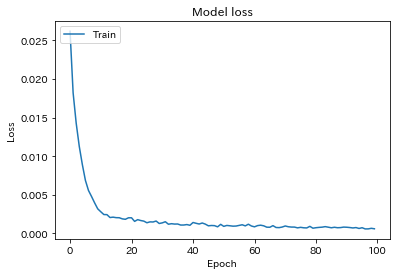

In [38]:
draw_history(history)

In [39]:
a,b,c,d=predict_result(new_model,x_train,scaler_list)

7/7 [==============================] - 1s 25ms/step


/home/matsumoto/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3715: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/matsumoto/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


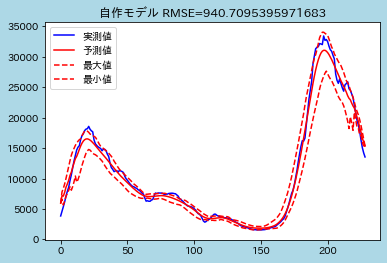

In [40]:
train_data_graph(a,b,c,d)

In [41]:
a,b,c,d=predict_result(new_model,x_test,scaler_list)

3/3 [==============================] - 0s 21ms/step


/home/matsumoto/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3715: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/matsumoto/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


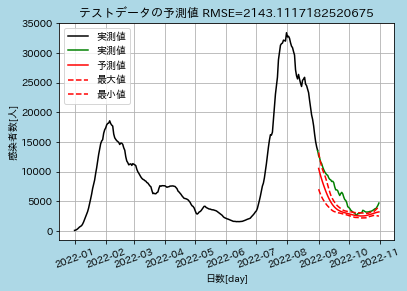

In [42]:
test_data_graph(a,b,c,d)

In [43]:
result=future_predict(new_model)
a=[]
b=[]
c=[]
d=[]
cnt=1
for values in result.values():
    if cnt<=LOOK_BACK-1:
        cnt+=1
        continue
    a.append(Mean(values))
    b.append(max(0,max(values)))
    c.append(max(0,min(values)))
    bottom,up=MeanCI(values)
    bottom=max(0,bottom)
    up=max(0,up)
    d.append((bottom,up))

/home/matsumoto/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3715: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/matsumoto/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


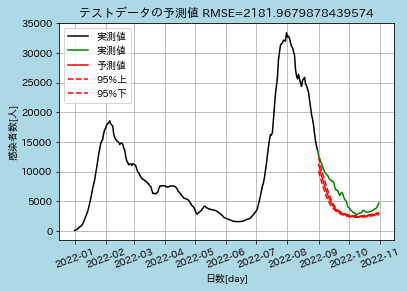

In [44]:
predict_result_graph(a,b,c,d)